In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_recall_curve, roc_curve, auc, precision_score, recall_score, f1_score,roc_auc_score
from keras.layers import Input, Dense
from keras.models import Model, load_model, Sequential
from keras import losses
from tensorflow.keras.callbacks import Callback
import tensorflow as tf
#Our Models 
from models.rand_autoencoder import RandAE
from preprocessing.scalers import own_scaler, mm_scaler, qs_mm_scaler
from models.isolation_forest_model import IsolationForestModel
from models.one_class_svm_model import OneClassSVMModel

In [111]:
df=pd.read_csv(r"creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [112]:
correlation_matrix=df.corr()

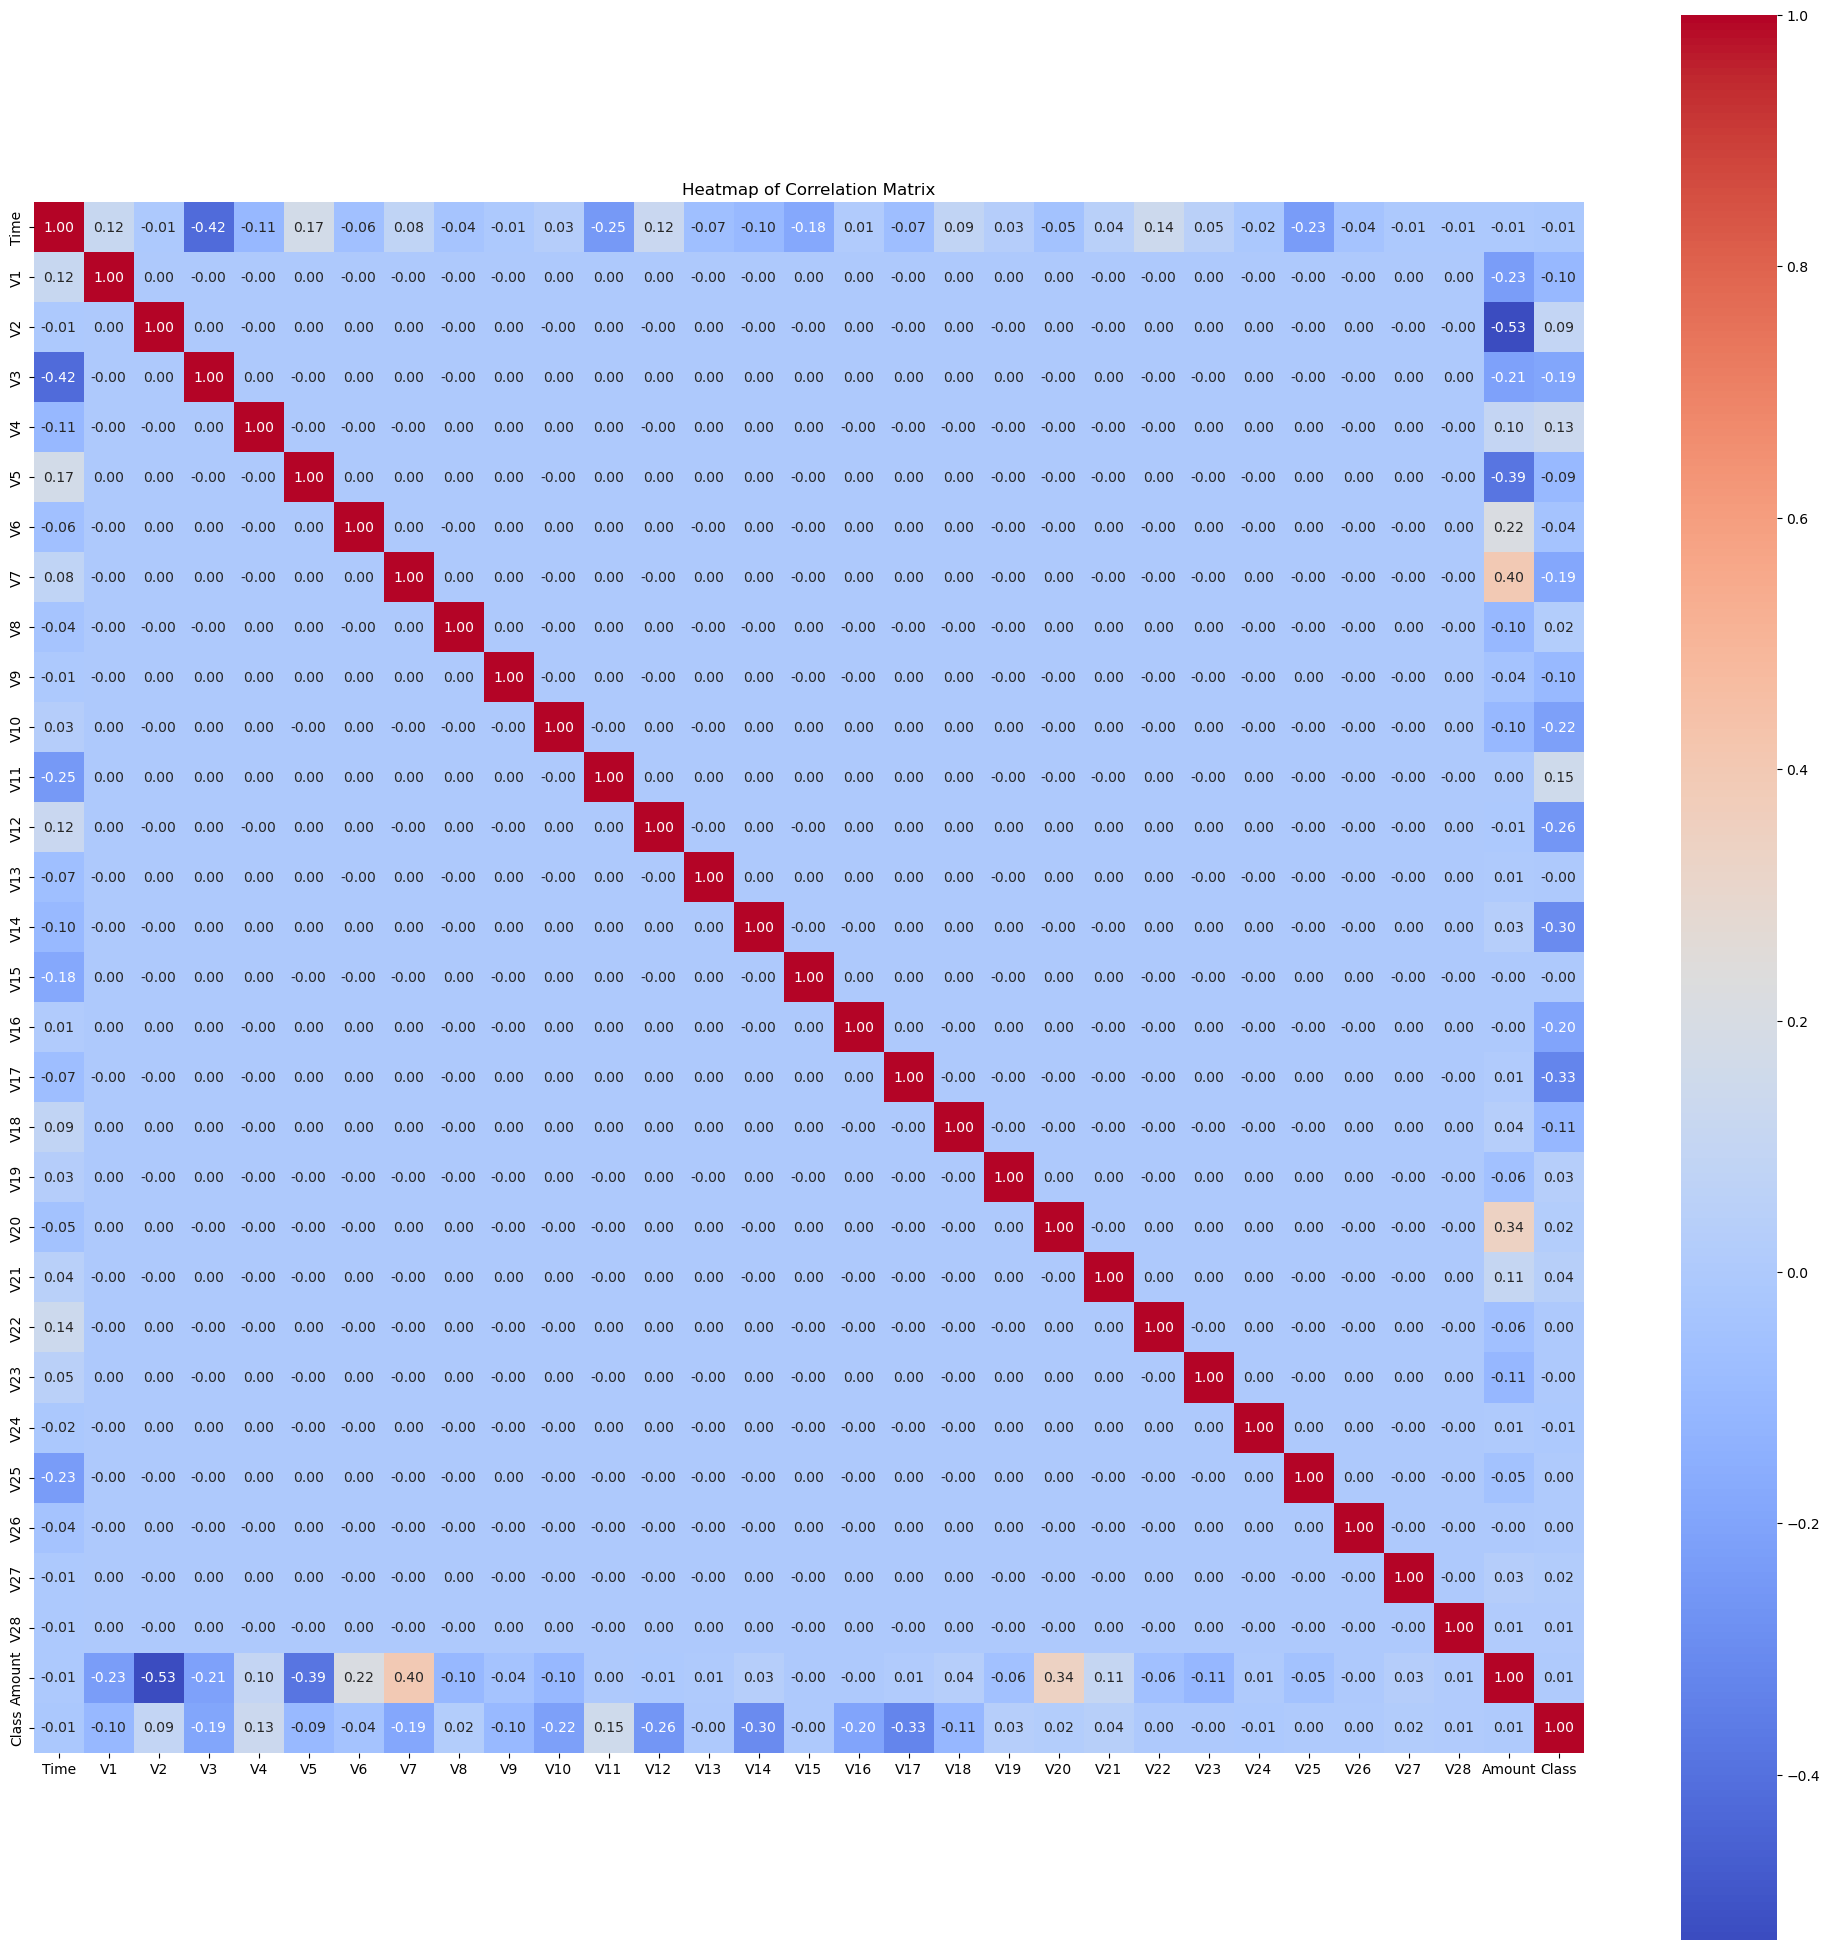

In [113]:
plt.figure(figsize=(25, 25))  # Set the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar=True)
plt.title('Heatmap of Correlation Matrix')
plt.show()

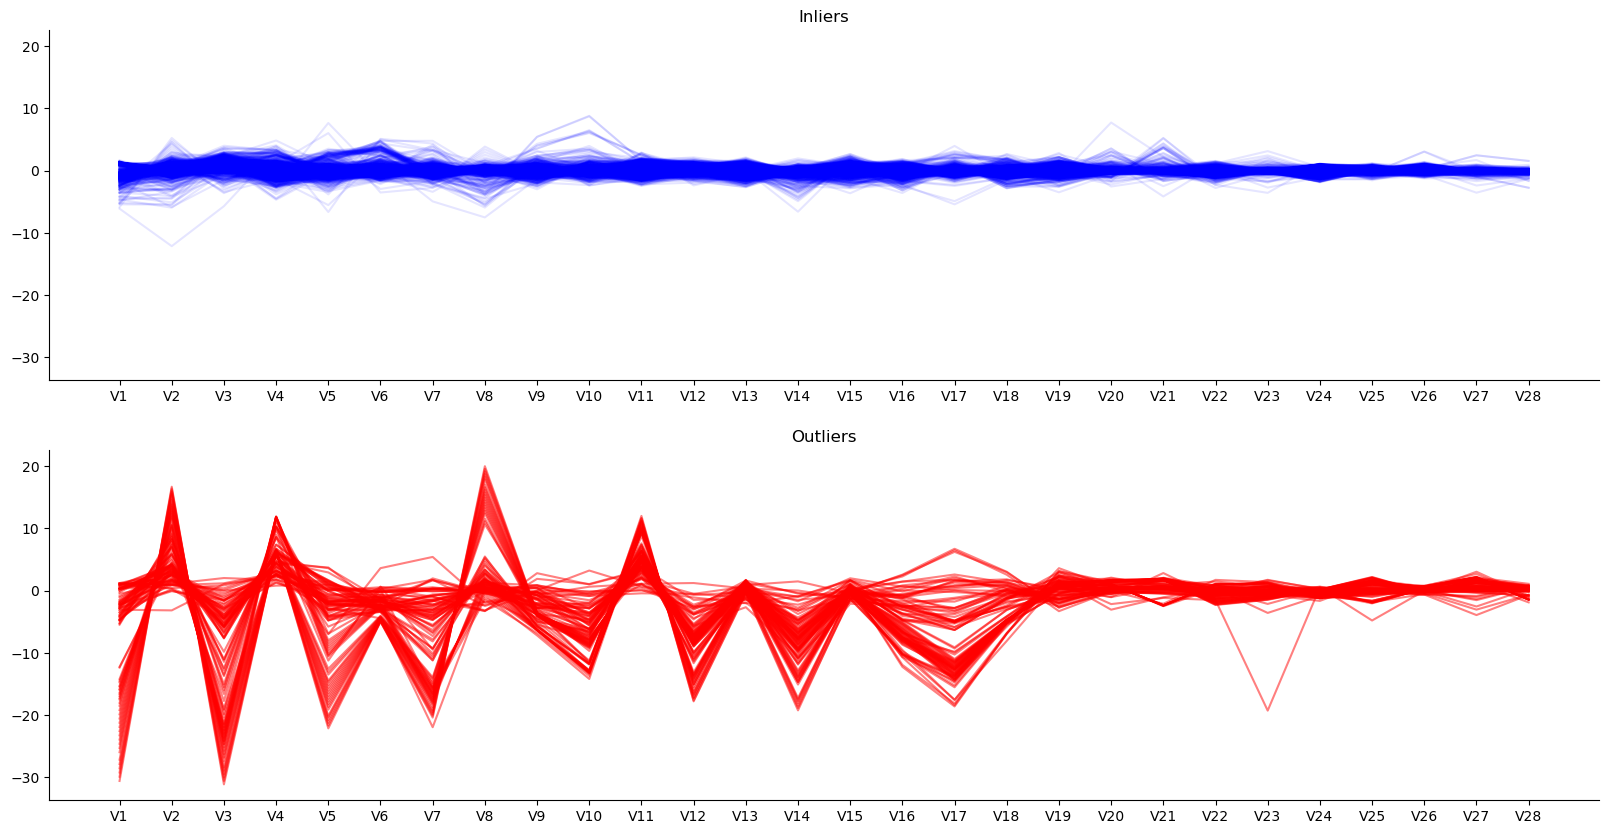

In [114]:
feature_cols = [col for col in df.columns if col.startswith("V")]

inlier_data = df[df.Class == 0].reset_index()
outlier_data = df[df.Class == 1].reset_index()

fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharey=True)
axs[0].plot(inlier_data.loc[:1000, feature_cols].T, c="blue", alpha=0.1)
axs[0].set_title("Inliers")
axs[1].plot(outlier_data.loc[:100, feature_cols].T, c="red", alpha=0.5)
axs[1].set_title("Outliers")
sns.despine()
plt.show()

<h1>Preprocessing</h1>
<p>
❌ Why Direct MinMax Scaling Can Be a Problem:
When you apply plain MinMaxScaler to the raw data:
    
1.It flattens the normal data close to zero
    
2.It pulls the outliers up (frauds), but now everything is in one narrow band

3.The model may not “see” the subtle variations in the normal data — or may be biased by the one extreme fraud

✅ Why My MyRobustScaler + MinMax Is Better:

1.I clip only the normal data range (10th–90th percentile)

2.You preserve anomalies outside that range — the likely frauds!

3.You get better scaling for the model without hiding the outliers
</p>

In [116]:
scaler = own_scaler

X = df.drop("Class", axis=1).values
y = df["Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)


In [117]:
scaled_data = pd.DataFrame(data=np.concatenate([X_train, y_train], axis=1), columns=df.columns)

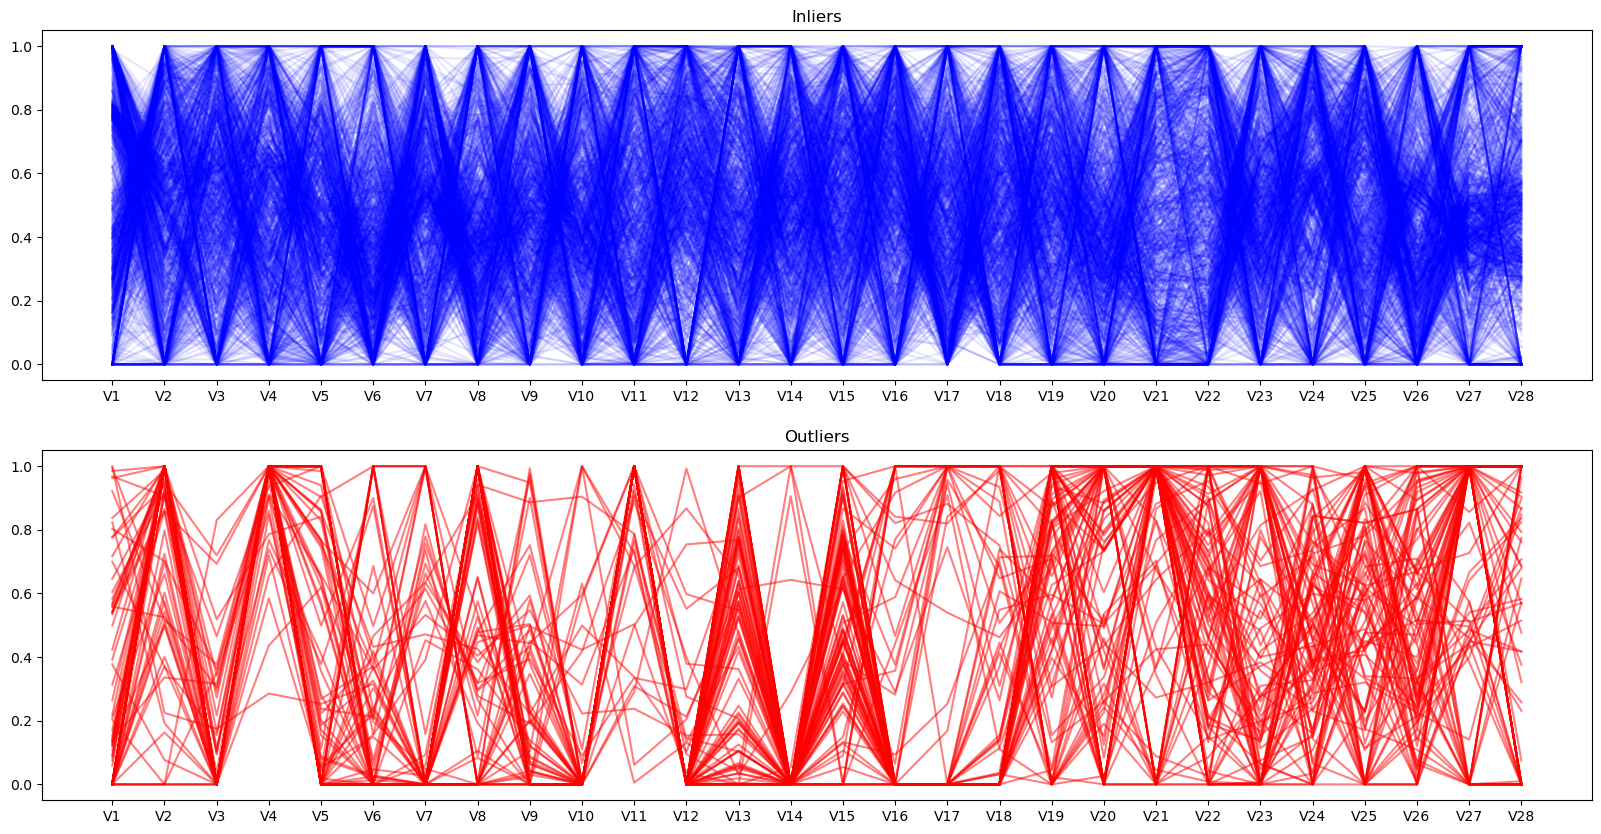

In [118]:
inlier_data = scaled_data[scaled_data.Class == 0].reset_index()
outlier_data = scaled_data[scaled_data.Class == 1].reset_index()

fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharey=True)
axs[0].plot(inlier_data.loc[:1000, feature_cols].T, c="blue", alpha=0.1)
axs[0].set_title("Inliers")
axs[1].plot(outlier_data.loc[:100, feature_cols].T, c="red", alpha=0.5)
axs[1].set_title("Outliers")
plt.show()

<h1>Autoencoders </h1><p>are unsupervised neural networks trained to reconstruct input data. In fraud detection:

Normal transactions dominate the dataset.

The autoencoder learns to reconstruct these well.

Fraudulent transactions, being different, lead to higher reconstruction error.

These high-error instances can be flagged as anomalies (potential frauds).</p>

<h1>Normal Autoencoder</h1>

In [19]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(16, activation='relu')(input_layer)
    encoded = Dense(8, activation='relu')(encoded)
    encoded = Dense(4, activation='relu')(encoded)
    decoded = Dense(8, activation='relu')(encoded)
    decoded = Dense(16, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)
    
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss="binary_crossentropy", run_eagerly=True,metrics=['accuracy'])
    return autoencoder

In [20]:
normal_ae = build_autoencoder(X_train.shape[1])
history1=normal_ae.fit(X_train, X_train, epochs=20, batch_size=1024, shuffle=True, validation_split=0.25)

Epoch 1/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - accuracy: 0.0476 - loss: 0.6852 - val_accuracy: 0.1706 - val_loss: 0.6576
Epoch 2/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy: 0.1841 - loss: 0.6509 - val_accuracy: 0.1974 - val_loss: 0.6353
Epoch 3/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.1972 - loss: 0.6331 - val_accuracy: 0.1946 - val_loss: 0.6285
Epoch 4/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.1971 - loss: 0.6277 - val_accuracy: 0.2061 - val_loss: 0.6247
Epoch 5/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 19s 112ms/step - accuracy: 0.2092 - loss: 0.6240 - val_accuracy: 0.2194 - val_loss: 0.6217
Epoch 6/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.2156 - loss: 0.6212 - val_accuracy: 0.2184 - val_loss: 0.6195
Epoch 7/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.2137 - loss: 0.6191 - val_accuracy: 0.2197 - val_loss: 0.6178
Epoch 8/20
167/167 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.2133 - loss: 0

<p>optimizer='adam': Efficient and adaptive optimizer for training.

loss='binary_crossentropy': Assumes input features are binary or normalized between 0 and 1.

Helps model minimize reconstruction error.

run_eagerly=True: Useful for debugging and step-by-step execution.
</p>

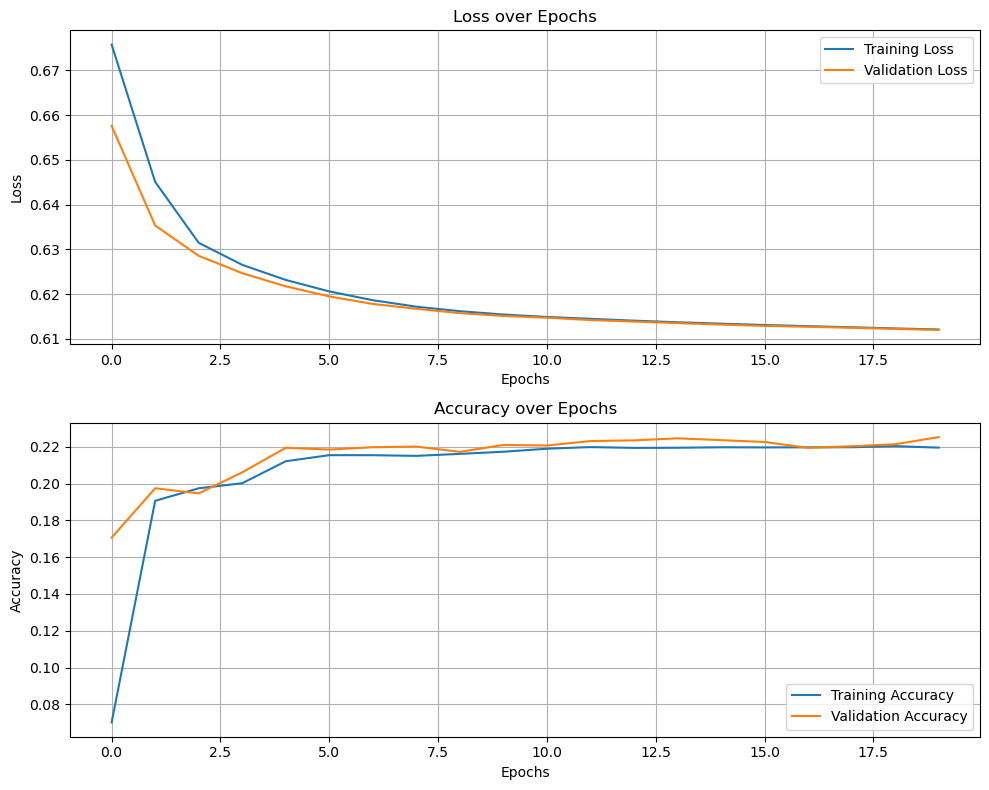

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot loss
axs[0].plot(history1.history['loss'], label='Training Loss')
axs[0].plot(history1.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot accuracy
axs[1].plot(history1.history['accuracy'], label='Training Accuracy')
axs[1].plot(history1.history['val_accuracy'], label='Validation Accuracy')
axs[1].set_title('Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


<h1>Randomize AE</h1>

<h1>Advantages of RandAE for Credit Card Fraud Detection</h1>
<p>Standard autoencoders can overfit to noisy or specific training data.

RandAE applies random structural dropout to weights (not just activations).

This forces the model to learn more general, robust patterns, making it better at detecting unseen types of fraud.

The randomness in connections encourages the network to focus on core patterns in the normal data.

Because RandAE randomly drops connections, it's harder for attackers to predict which features matter most.
<table>
    <tr>
        <th>Model</th>
        <th>Detects Fraud?</th>
        <th>Overfitting Risk</th>
        <th>Needs Labels?</th>
        <th>Resilient to Noise?</th>
    </tr>
    <tr>
        <td>Autoencoder</td>
        <td>Yes</td>
        <td>Medium</td>
        <td>No</td>
        <td>Medium</td>
    </tr>
    <tr>
        <td>RandAE</td>
        <td>Yes ✅</td>
        <td>Low ✅</td>
        <td>No ✅</td>
        <td>High ✅</td>
    </tr>
    </table></p>

The randomization aspect comes from applying dropout-like masks to the weights of dense layers, which introduces sparsity and can enhance robustness or generalization
Dropout Ratio (drop_ratio): The probability of setting a weight to zero in the weight matrices (default 0.35), introducing sparsity via random masks.

In [127]:
# Test compile
Rand_Ae = RandAE(31, [31, 16,8, 16, 31])  # Adjust input_dim to match your data
Rand_Ae.compile(optimizer="adam", loss="binary_crossentropy", run_eagerly=True)

In [128]:
# structure
Rand_Ae.summary()

Model: "rand_ae_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_0 (Dense)                     │ (None, 31)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_1 (Dense)                     │ (None, 16)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_3 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_4 (Dense)                     │ (None, 31)                  │             527 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 31)                  │             992 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,303 (12.90 KB)

 Trainable params: 3,303 (12.90 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
Rand_Ae= RandAE(X_train.shape[1], [30], drop_ratio=0.35)  # shallow AE
Rand_Ae.compile(optimizer="adam", loss="binary_crossentropy", run_eagerly=True, metrics=['accuracy'])

In [134]:
# Train with dynamic dropout
history = Rand_Ae.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.1224 - loss: 0.6749 - val_accuracy: 0.3016 - val_loss: 0.5774
Epoch 2/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.3176 - loss: 0.5548 - val_accuracy: 0.3698 - val_loss: 0.5049
Epoch 3/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.3777 - loss: 0.4962 - val_accuracy: 0.3922 - val_loss: 0.4791
Epoch 4/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.3922 - loss: 0.4760 - val_accuracy: 0.3929 - val_loss: 0.4689
Epoch 5/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.3965 - loss: 0.4670 - val_accuracy: 0.3957 - val_loss: 0.4625
Epoch 6/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.4014 - loss: 0.4611 - val_accuracy: 0.4081 - val_loss: 0.4576
Epoch 7/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.4176 - loss: 0.4566 - val_accuracy: 0.4246 - val_loss: 0.4542
Epoch 8/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.4286 - loss: 0.4535 - 

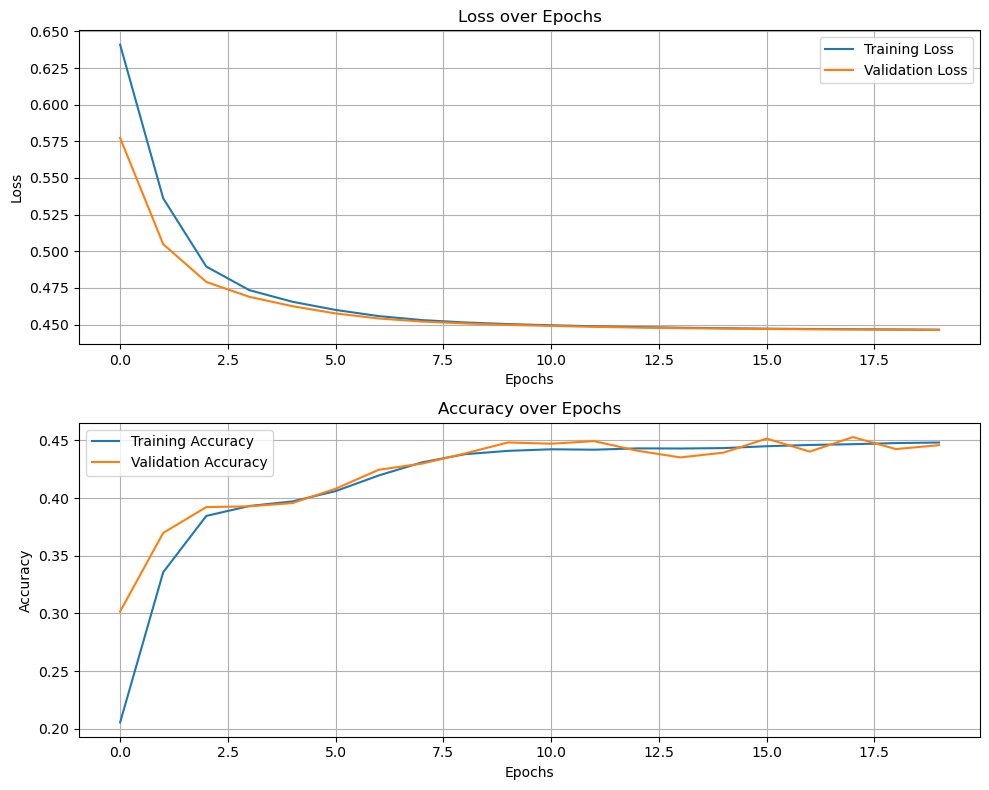

In [135]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot loss
axs[0].plot(history.history['loss'], label='Training Loss')
axs[0].plot(history.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot accuracy
axs[1].plot(history.history['accuracy'], label='Training Accuracy')
axs[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[1].set_title('Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

<h1>Isolation Forest</h1>

In [41]:
# Adjust contamination/nu based on your fraud rate
iso_model = IsolationForestModel(contamination=0.05, random_state=1)
iso_model.fit(X_train)

In [42]:
iso_pred = iso_model.predict(X_test)

In [44]:
iso_pred = np.where(iso_pred == 1, 0, 1)

<h1>One Class SVM
</h1>

In [46]:
svm_model = OneClassSVMModel(nu=0.01)
svm_model.fit(X_train)

In [47]:
svm_pred = svm_model.predict(X_test)

In [48]:
svm_pred = np.where(svm_pred == 1, 0, 1)

<h1>Results from all Models</h1>

In [138]:
input_data = X_test
input_labels = y_test

In [140]:
results = []

def evaluate_model(name, model, input_data, input_labels, is_autoencoder=True):
    print(f"\n=== Results for {name} ===")

    if is_autoencoder:
        pred = model.predict(input_data)
        reconstruction_loss = np.square(pred - input_data).mean(axis=1)

        # === Custom threshold search for best F1 ===
        thresholds = np.linspace(reconstruction_loss.min(), reconstruction_loss.max(), 10)

        best_threshold = None
        best_f1 = 0
        best_metrics = {}
        best_pred = None

        for t in thresholds:
            outlier_pred = np.where(reconstruction_loss > t, 1, 0)
            f1 = f1_score(input_labels, outlier_pred)

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = t
                best_pred = outlier_pred
                best_metrics = {
                    'f1_score': f1,
                    'precision': precision_score(input_labels, outlier_pred),
                    'recall': recall_score(input_labels, outlier_pred),
                    'accuracy': accuracy_score(input_labels, outlier_pred),
                    'confusion_matrix': confusion_matrix(input_labels, outlier_pred)
                }

        outlier_pred = best_pred
        outlier_scores = reconstruction_loss  # still used for ROC/PRC
        print(f"Selected threshold = {best_threshold:.6f} with F1 = {best_f1:.4f}")

    else:
        raw_pred = model.predict(input_data)
        outlier_pred = np.where(raw_pred == -1, 1, 0)
        if hasattr(model, "decision_function"):
            outlier_scores = -model.decision_function(input_data)
        else:
            outlier_scores = outlier_pred

    # Store for plotting
    results.append({
        "name": name,
        "y_true": input_labels,
        "y_pred": outlier_pred,
        "scores": outlier_scores
    })

    # Print report
    cr = classification_report(input_labels, outlier_pred)
    print(cr)



In [142]:
# Your corrected model names
evaluate_model("RandAE", Rand_Ae, input_data, input_labels, is_autoencoder=True)
evaluate_model("NormalAE", normal_ae, input_data, input_labels, is_autoencoder=True)
evaluate_model("Isolation Forest", iso_model, input_data, input_labels, is_autoencoder=False)
evaluate_model("One-Class SVM", svm_model, input_data, input_labels, is_autoencoder=False)


=== Results for RandAE ===
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
Selected threshold = 0.027010 with F1 = 0.8308
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


=== Results for NormalAE ===
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step
Selected threshold = 0.184162 with F1 = 0.2994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.21      0.51      0.30        98

    accuracy                           1.00     56962
   macro avg       0.61      0.75      0.65     56962
weighted avg       1.00      1.00      1.00     56962


=== Results for Isolation Forest ===
              precision    recall  f1-score   support

           0 

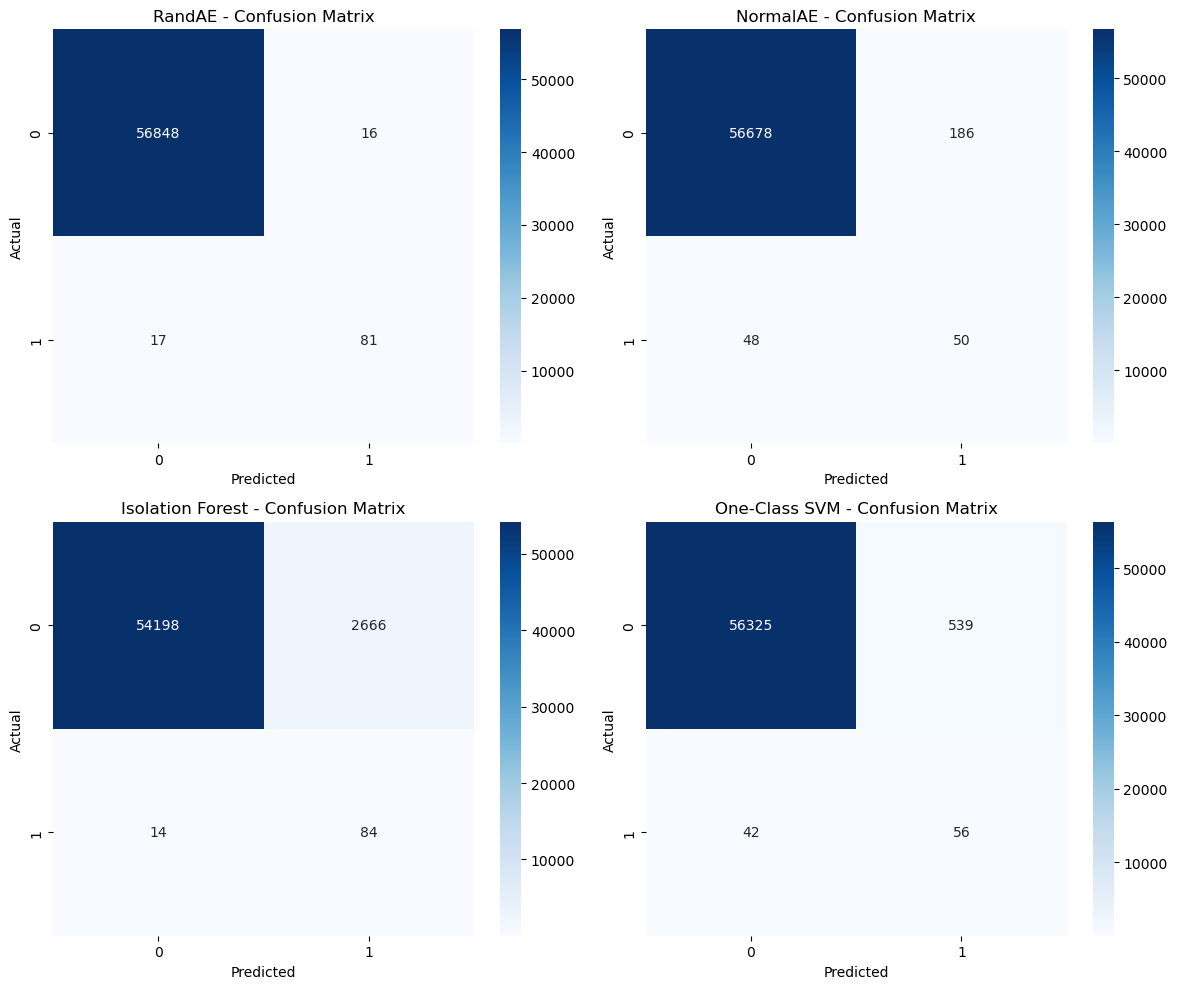

In [143]:
# Plot Confusion Matrices
plt.figure(figsize=(12, 10))
for i, res in enumerate(results):
    plt.subplot(2, 2, i + 1)
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{res['name']} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

<h1>Isolation forest Aggressive detection behavior</h1>
<p>Isolation Forest often favors recall over precision by flagging more points as anomalies.

This results in more TPs, but also more FPs, which explains why precision is extremely low (0.03).

So, it casts a wide net—you catch more anomalies (good recall), but also get lots of normal points wrongly flagged (bad precision).</p>

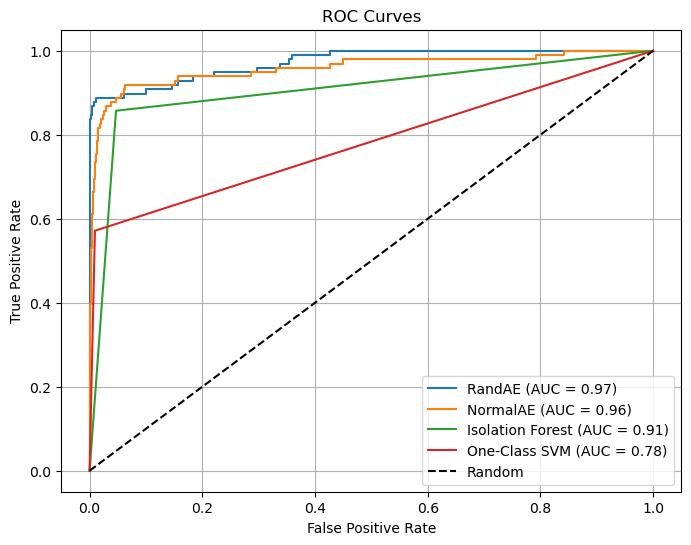

In [145]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))
for res in results:
    fpr, tpr, _ = roc_curve(res["y_true"], res["scores"])
    roc_auc = roc_auc_score(res["y_true"], res["scores"])
    plt.plot(fpr, tpr, label=f"{res['name']} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

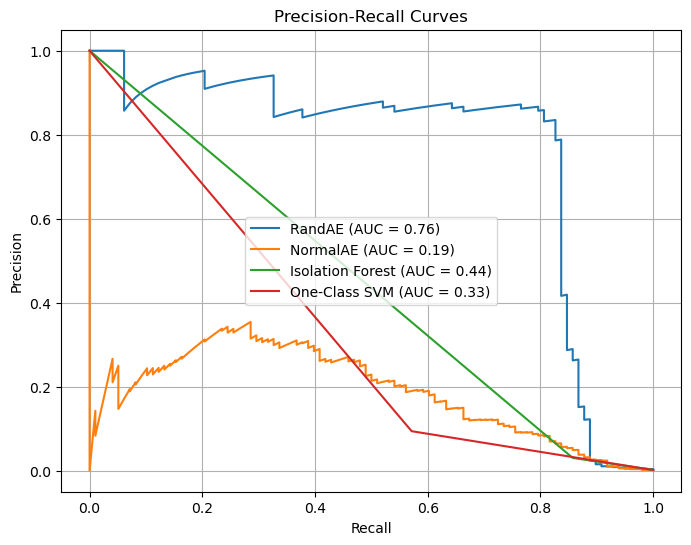

In [146]:
# Plot Precision-Recall Curves
plt.figure(figsize=(8, 6))
for res in results:
    precision, recall, _ = precision_recall_curve(res["y_true"], res["scores"])
    prc_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{res['name']} (AUC = {prc_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()